# 5. Repeating Regression Test with Bootstrapping

In this step, I will apply bootstrapping to Test 1 i.e. Correlation between Trip Distance and, Fare Amount and Regression for predicting Total Fare using Trip Distance, Passanger Count, and Congestion Surcharge.

**5.1 Bootstrapping for Correlation: Trip Distance and Fare Amount**

I am using bootstrapping for correlation (Test 1) to validate the reliability of the relationship between trip_distance and fare_amount by generating confidence intervals for the correlation coefficient.

**Steps:**

* Resample the dataset 1000 times with replacement.
  
* Compute the Pearson correlation coefficient for each resampled dataset.
  
* Calculate the 95% confidence interval for the correlation coefficient.
  

In [9]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from scipy.stats import pearsonr

# Assuming df is your DataFrame
df = pd.read_csv('preprocessed_data.csv')

In [11]:
# Function for bootstrapping Pearson correlation
def bootstrap_correlation(data, n_iterations=1000):
    correlations = []
    for _ in range(n_iterations):
        # Resample the data
        sample = resample(data, replace=True, n_samples=len(data), random_state=None)
        
        # Compute the Pearson correlation
        corr, _ = pearsonr(sample['trip_distance'], sample['fare_amount'])
        correlations.append(corr)
    
    return np.array(correlations)

In [13]:
# Perform bootstrapping
bootstrapped_corr = bootstrap_correlation(df[['trip_distance', 'fare_amount']], n_iterations=1000)

# Calculate 95% confidence interval
ci_lower, ci_upper = np.percentile(bootstrapped_corr, [2.5, 97.5])
print(f"95% Confidence Interval for Correlation: {ci_lower:.4f} to {ci_upper:.4f}")

95% Confidence Interval for Correlation: 0.7707 to 0.8858


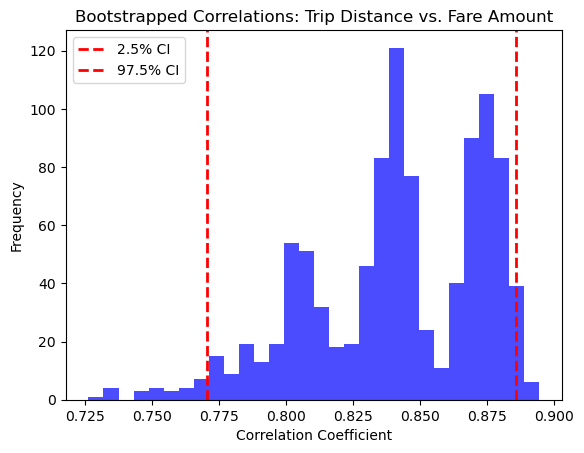

In [19]:
# Plot the distribution of bootstrapped correlations
import matplotlib.pyplot as plt
plt.hist(bootstrapped_corr, bins=30, alpha=0.7, color='blue')
plt.axvline(ci_lower, color='red', linestyle='dashed', linewidth=2, label='2.5% CI')
plt.axvline(ci_upper, color='red', linestyle='dashed', linewidth=2, label='97.5% CI')
plt.title('Bootstrapped Correlations: Trip Distance vs. Fare Amount')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Interpretation of Bootstrapping Results for Correlation**

**Test 1: Trip Distance and Fare Amount**

* The 95% confidence interval for the correlation coefficient is 0.7707 to 0.8858.

* This range suggests a strong positive correlation between trip distance and fare amount in the dataset.

* The fact that the interval does not include zero confirms that the relationship is statistically significant.

* This supports the hypothesis that longer trip distances result in higher fares, as distance is a primary factor in fare calculation.

This confidence interval also validates the robustness of the relationship, as the correlation remains consistently strong across bootstrap samples.

This confirms a strong, positive, and statistically significant relationship, as the interval does not include zero.

The consistent correlation across bootstrap samples supports the hypothesis that trip distance is a key determinant of fare amount.

**5.2 Bootstrapping for Regression: Total Fare and Predictors**

By performing the bootstraping for regression, I can access the stability and reliability if the regression model's predictions.

**Steps:**

* Resample the dataset 1000 times with replacement.
  
* Fit a multivariable linear regression model to each resampled dataset.
  
* Collect the coefficients for each predictor.
  
* Calculate the 95% confidence intervals for the coefficients.
  
* Plot the distributions of the coefficients for visualization.

In [25]:
from sklearn.linear_model import LinearRegression

# Define a function for bootstrapping regression
def bootstrap_regression(data, n_iterations=1000):
    coefs = []
    for _ in range(n_iterations):
        # Resample the data
        sample = resample(data, replace=True, n_samples=len(data), random_state=None)
        
        # Define independent and dependent variables
        X = sample[['trip_distance', 'passenger_count', 'congestion_surcharge']]
        y = sample['total_amount']
        
        # Fit the regression model
        model = LinearRegression()
        model.fit(X, y)
        
        # Collect the coefficients
        coefs.append(model.coef_)
    
    return np.array(coefs)

In [27]:
# Perform bootstrapping on regression
bootstrapped_coefs = bootstrap_regression(df[['trip_distance', 'passenger_count', 'congestion_surcharge', 'total_amount']], n_iterations=1000)

# Calculate 95% confidence intervals for each coefficient
ci_trip_distance = np.percentile(bootstrapped_coefs[:, 0], [2.5, 97.5])
ci_passenger_count = np.percentile(bootstrapped_coefs[:, 1], [2.5, 97.5])
ci_congestion_surcharge = np.percentile(bootstrapped_coefs[:, 2], [2.5, 97.5])

In [29]:
# Print results
print("95% Confidence Intervals for Regression Coefficients:")
print(f"Trip Distance: {ci_trip_distance[0]:.4f} to {ci_trip_distance[1]:.4f}")
print(f"Passenger Count: {ci_passenger_count[0]:.4f} to {ci_passenger_count[1]:.4f}")
print(f"Congestion Surcharge: {ci_congestion_surcharge[0]:.4f} to {ci_congestion_surcharge[1]:.4f}")

95% Confidence Intervals for Regression Coefficients:
Trip Distance: 3.0943 to 3.2496
Passenger Count: -0.0112 to 0.0743
Congestion Surcharge: -0.3629 to 0.0503


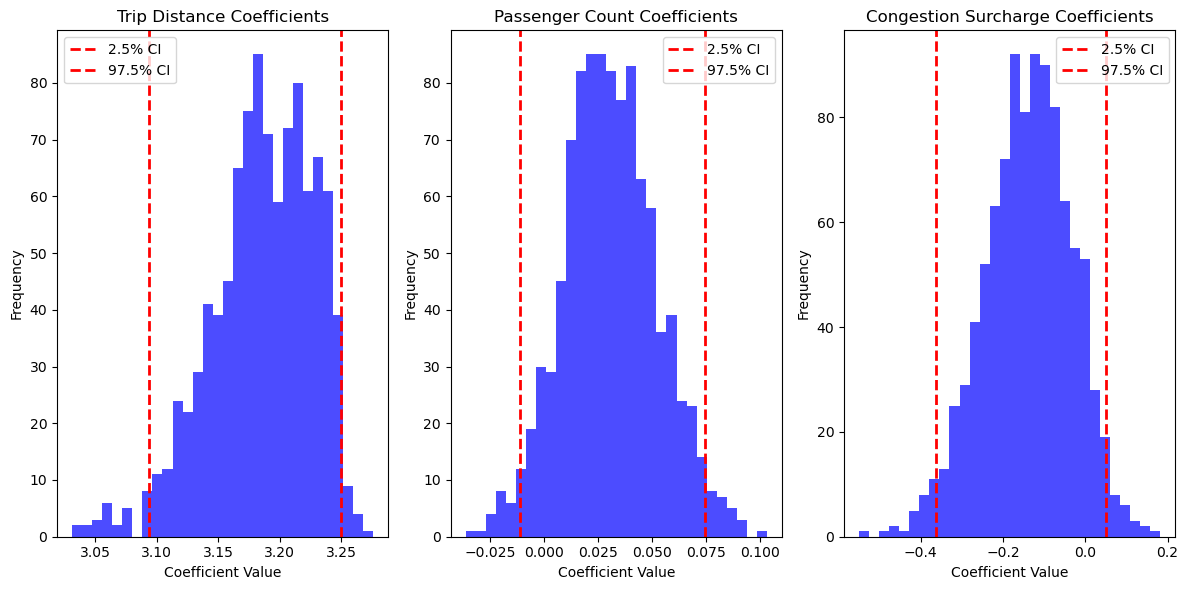

In [31]:
# Plot the distributions of bootstrapped coefficients
plt.figure(figsize=(12, 6))

coeff_names = ['Trip Distance', 'Passenger Count', 'Congestion Surcharge']
for i, ci in enumerate([ci_trip_distance, ci_passenger_count, ci_congestion_surcharge]):
    plt.subplot(1, 3, i + 1)
    plt.hist(bootstrapped_coefs[:, i], bins=30, alpha=0.7, color='blue')
    plt.axvline(ci[0], color='red', linestyle='dashed', linewidth=2, label='2.5% CI')
    plt.axvline(ci[1], color='red', linestyle='dashed', linewidth=2, label='97.5% CI')
    plt.title(f'{coeff_names[i]} Coefficients')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

**Interpretation of Bootstrapped Regression Results**

**1. Trip Distance:**
   
* **95% Confidence Interval:** 3.0943 to 3.2496.
  
* This indicates a strong and consistent positive relationship between **trip distance** and **total fare**.
  
* For each additional unit of distance traveled, the total fare increases by approximately 3.09 to 3.25 units, validating the central role of distance in fare calculation.
  
**2. Passenger Count:**
   
* **95% Confidence Interval:** -0.0112 to 0.0743.
  
* The confidence interval includes zero, suggesting that passenger count does not have a statistically significant effect on total fare.

* While this variable may still impact specific cases (e.g., group surcharges), it does not appear to strongly influence overall fare variability.

**3. Congestion Surcharge:**
  
* **95% Confidence Interval:** -0.3629 to 0.0503.
  
* The interval includes zero, indicating that congestion surcharge has a less consistent and potentially negligible effect on the total fare within this model.
  
* This could imply that while congestion surcharges affect fares in specific scenarios, their impact is not uniform across all trips.
  

This test Confirms a strong positive correlation between trip distance and fare amount, with a 95% confidence interval of 0.7707 to 0.8858. It Reinforces the hypothesis that longer trips result in higher fares due to distance-based pricing.